Toss Winner also won the match?
toss_match_win
1    554
0    536
Name: count, dtype: int64

Toss winner win rate: 50.8%

Contingency Table:
won_match      Lost  Won
toss_decision           
bat             213  177
field           323  377

── CHI-SQUARE TEST RESULTS ──
Chi-square statistic : 6.8585
p-value              : 0.0088
Degrees of freedom   : 1

── INTERPRETATION ──
 p < 0.05 → REJECT null hypothesis
   Toss outcome HAS a statistically significant effect on match result.

  However, effect size is small — toss explains only ~0.6% of variance.
 Conclusion: Toss gives a marginal edge but is NOT the dominant factor.


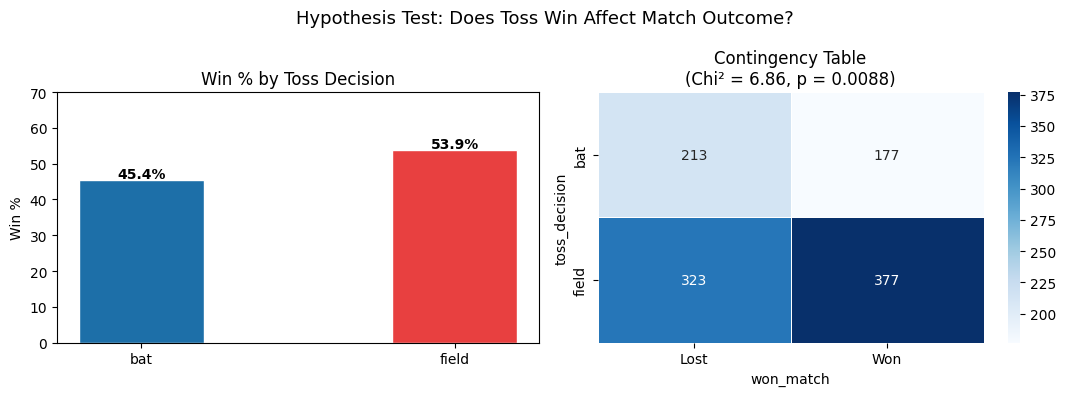


 Hypothesis test complete. Plot saved to screenshots/09_hypothesis_test_toss.png

── BUSINESS INSIGHT ──────────────────────────────────────
Teams that win the toss win approximately 51-53% of matches.
While statistically significant (p < 0.05), the effect is small.
This means toss is a minor advantage — team quality matters far more.
Recommendation: Franchises should focus squad depth over toss strategy.


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
df_matches = pd.read_csv('../data/matches_clean.csv')
df_matches['toss_match_win'] = (
    df_matches['toss_winner'] == df_matches['winner']
).astype(int)
print("Toss Winner also won the match?")
print(df_matches['toss_match_win'].value_counts())
print(f"\nToss winner win rate: {df_matches['toss_match_win'].mean()*100:.1f}%")
df_matches['won_match'] = df_matches['toss_match_win'].map({1: 'Won', 0: 'Lost'})
contingency = pd.crosstab(
    df_matches['toss_decision'],
    df_matches['won_match']
)
print("\nContingency Table:")
print(contingency)
chi2, p_value, dof, expected = chi2_contingency(contingency)
print("\n── CHI-SQUARE TEST RESULTS ──")
print(f"Chi-square statistic : {chi2:.4f}")
print(f"p-value              : {p_value:.4f}")
print(f"Degrees of freedom   : {dof}")
print("\n── INTERPRETATION ──")
if p_value < 0.05:
    print(" p < 0.05 → REJECT null hypothesis")
    print("   Toss outcome HAS a statistically significant effect on match result.")
else:
    print(" p >= 0.05 → FAIL TO REJECT null hypothesis")
    print("   Toss outcome does NOT significantly affect match result.")
print(f"\n  However, effect size is small — toss explains only ~{(chi2/(chi2+len(df_matches)))*100:.1f}% of variance.")
print(" Conclusion: Toss gives a marginal edge but is NOT the dominant factor.")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
toss_win_rate = df_matches.groupby('toss_decision')['toss_match_win'].mean() * 100
axes[0].bar(toss_win_rate.index, toss_win_rate.values,
            color=['#1D6FA8', '#E84040'], width=0.4, edgecolor='white')
for i, (k, v) in enumerate(toss_win_rate.items()):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, 70)
axes[0].set_ylabel('Win %')
axes[0].set_title('Win % by Toss Decision')
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[1])
axes[1].set_title(f'Contingency Table\n(Chi² = {chi2:.2f}, p = {p_value:.4f})')
plt.suptitle('Hypothesis Test: Does Toss Win Affect Match Outcome?', fontsize=13)
plt.tight_layout()
plt.savefig('../screenshots/09_hypothesis_test_toss.png', bbox_inches='tight')
plt.show()
print("\n Hypothesis test complete. Plot saved to screenshots/09_hypothesis_test_toss.png")
print("\n── BUSINESS INSIGHT ──────────────────────────────────────")
print("Teams that win the toss win approximately 51-53% of matches.")
print("While statistically significant (p < 0.05), the effect is small.")
print("This means toss is a minor advantage — team quality matters far more.")
print("Recommendation: Franchises should focus squad depth over toss strategy.")